### Copyright Matlantis Corp. as contributors to Matlantis contrib project

[JP]
##  ポリマーの自由体積計算
- シミュレーションは[こちらの論文](https://www.mdpi.com/2079-3197/7/2/27)を参考に実装した。
- 本notebookではポリマーのモデリングを行う。

[EN]
##  Calculation of Polymer Free Volume
- The simulation was implemented based on [this paper](https://www.mdpi.com/2079-3197/7/2/27)
- This notebook focuses on polymer modeling.

In [1]:
# Standard library imports
from pathlib import Path
from typing import Optional

# Third party imports
from ase.io import write
from ase.optimize import FIRE
from radonpy.core.poly import polymerize_MolFromSmiles
from rdkit import Chem
from rdkit.Chem import Descriptors

# Local application/library specific imports
from pfcc_extras.structure.ase_rdkit_converter import smiles_to_atoms
from pfcc_extras.liquidgenerator.liquid_generator import LiquidGenerator
from pfp_api_client.pfp.calculators.ase_calculator import ASECalculator
from pfp_api_client.pfp.estimator import Estimator, EstimatorCalcMode

In [2]:
# parameters
output_dir = "output_modeling"
polymer_name = "UItem"
polymer_smiles = "C1=C7C(=CC=C1OC2=CC=C(C=C2)C(C)(C)C3=CC=C(C=C3)OC4=CC5=C(C=C4)C(N(C5=O)C6=CC(*)=CC=C6)=O)C(N(*)C7=O)=O"
target_mw = 2500

model_version = "v8.0.0"
calc_mode = EstimatorCalcMode.R2SCAN_PLUS_D3

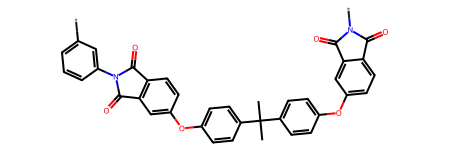

In [3]:
Chem.MolFromSmiles(polymer_smiles)

In [4]:
# Create a folder
if not Path(output_dir).exists():
    Path(output_dir).mkdir(parents=True)

estimator = Estimator(model_version=model_version, calc_mode=calc_mode)
calculator = ASECalculator(estimator)

[JP]
- 本notebookではradonpyを用いてポリマーのSmilesを作成し、smiles_to_atomsでポリマーの3D構造を作成する。
- 必要に応じて[EMC](https://redirect.matlantis.com/api/docs/ja/matlantis-contrib/build_polymer_using_EMC_example/build_liquids.html#build-a-liquid-geometry-using-emc)などを用いて3D構造を作成してください。

[EN]
- This notebook generates polymer SMILES via RadonPy and converts them to 3D structures with smiles_to_atoms.
- If necessary, use [EMC](https://redirect.matlantis.com/api/docs/ja/matlantis-contrib/build_polymer_using_EMC_example/build_liquids.html#build-a-liquid-geometry-using-emc) etc. for 3D structure generation.

In [5]:
def create_polymer_atoms(
    smiles: str, 
    output_path: str, 
    calculator,
    target_mw: float = 2000.0, 
    terminal_group: str = "C", 
    force_max: float = 0.1
) -> None:
    """
    Generates a polymer chain from a monomer SMILES string, 
    optimizes the 3D structure, and saves it to a file.
    """
    # Calculate the degree of polymerization
    monomer_mol = Chem.MolFromSmiles(smiles)
    if monomer_mol is None:
        raise ValueError(f"Invalid SMILES string provided: {smiles}")

    monomer_weight = Descriptors.MolWt(monomer_mol)
    num_units = round(target_mw / monomer_weight)

    # Generate polymer SMILES via RadonPy
    polymer_mol = polymerize_MolFromSmiles(smiles, n=num_units, terminal=terminal_group)
    polymer_smiles = Chem.MolToSmiles(polymer_mol)

    # Convert SMILES to 3D structure (ASE Atoms)
    atoms = smiles_to_atoms(polymer_smiles, maxAttempts=1000000)
    
    # Attach the passed calculator to the atoms object
    atoms.calc = calculator
    
    # Structural optimization using FIRE
    optimizer = FIRE(atoms, logfile=None)
    optimizer.run(fmax=force_max)

    # Write the resulting structure to the specified path
    atoms.write(output_path)

In [6]:
def pack_polymer(
    input_structure_file: str, 
    output_directory: str, 
    calculator,
    system_name: str, 
    num_chains: int = 10, 
    target_density: float = 0.1
) -> None:
    """
    Packs polymer chains into a box to create an amorphous system.
    """
    # Setup configuration for the LiquidGenerator
    generation_params = {
        "density": target_density,
        "composition": [
            {
                "name": system_name, 
                "structure": input_structure_file, 
                "number": num_chains, 
                "density": target_density, 
            },
        ],
        "calc_pbc": True,
        "packmol_bin": "./packmol/packmol"
    }
    
    # Build the packed system
    generator = LiquidGenerator(**generation_params)
    packed_system = generator.run()
    
    # Attach the passed calculator
    packed_system.calc = calculator
    
    # Relax the system to remove high-energy overlaps
    dynamics = FIRE(packed_system, trajectory=None, logfile=None)
    dynamics.run(fmax=0.1)
    
    # Save the final liquid structure
    output_path = Path(output_directory) / f"{system_name}_liq.xyz"
    write(str(output_path), packed_system)

In [7]:
create_polymer_atoms(polymer_smiles, f"{output_dir}/{polymer_name}.xyz", calculator, target_mw=target_mw)

In [8]:
pack_polymer(f"{output_dir}/{polymer_name}.xyz", output_dir, calculator, polymer_name)

Complete generation2.9744980335235596 s
Complete add property0.04624748229980469 s


In [9]:
%load_ext watermark
%watermark -n -u -v -iv -w

Last updated: Wed, 25 Feb 2026

Python implementation: CPython
Python version       : 3.13.8
IPython version      : 9.7.0

ase           : 3.27.0
pfcc_extras   : 0.13.0
pfp_api_client: 2.2.0
radonpy       : 0.2.9
rdkit         : 2024.9.4

Watermark: 2.6.0

